Saving heart.csv to heart.csv
<bound method NDFrame.head of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  

Text(50.722222222222214, 0.5, 'Actual')

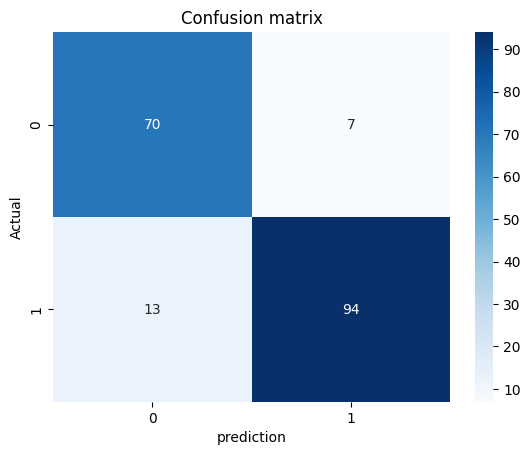

In [ ]:
from google.colab import files
uploaded = files.upload()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
df = pd.read_csv('heart.csv')
print(df.head)
label_encoder = LabelEncoder()
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = label_encoder.fit_transform(df[col])

X = df.drop('HeartDisease',axis=1)
y = df['HeartDisease']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2,random_state=42)

model = RandomForestClassifier(n_estimators = 100,random_state=99)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print('accuracy', accuracy_score(y_test,y_pred))
print('classification report', classification_report(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion matrix')
plt.xlabel('prediction')
plt.ylabel('Actual')